In [2]:
# !pip install librosa

Посмотрим на примере и визуализируем аудиотрек. Для визуализации используем библиотеку librosa, которая позволяет загружать и конвертировать аудио. Возьмём трек — 45-секундную запись Венгерского танца И. Брамса в концертном зале. Трек автоматически загружается в коде.

Вызовем метод load и передадим в него загруженный аудио файл, sample rate композиции оставим  исходный. При необходимости можно изменить его при загрузке с помощью атрибута sr — sample rate. 

In [ ]:
import requests
import os
import librosa


url = "https://raw.githubusercontent.com/librosa/data/main/audio/Hungarian_Dance_number_5_-_Allegro_in_F_sharp_minor_(string_orchestra).hq.ogg"
response = requests.get(url, stream=True)

os.mkdir("data/music")
with open("data/music/Hungarian_Dance_number_5.ogg", "wb") as f:
    f.write(response.content)

# загрузка аудиофайла
audio_path = 'data/music/Hungarian_Dance_number_5.ogg'

# метод возвразает загруженный сигнал и расчетный sample rate

signal, sample_rate = librosa.load(audio_path, sr=None)

print(f"Частота дискретизации: {sample_rate} Гц")
print(f"Количество сэмплов: {len(signal)}")
print(f"Длительность: {len(signal)/sample_rate:.2f} секунд")

/Users/papa/Documents/Практикум/Deep learning Engineer/dle_practicum/Sprint 4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Частота дискретизации: 44100 Гц
Количество сэмплов: 2021760
Длительность: 45.84 секунд


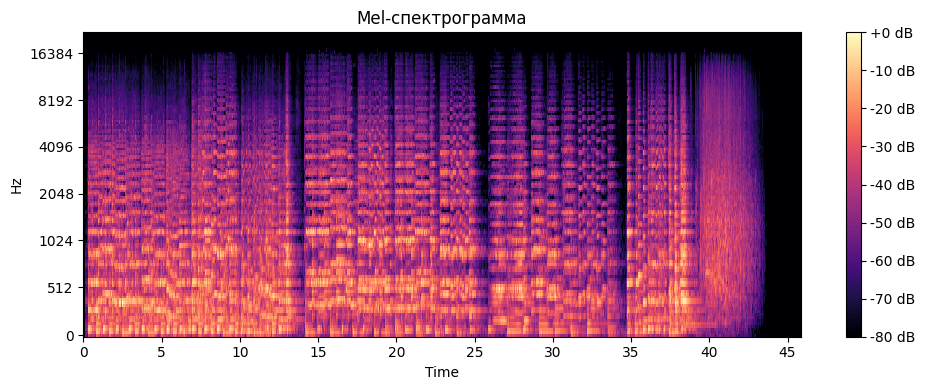

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Параметры для спектрограммы
n_fft = 2048  # размер окна для FFT

hop_length = 512  # шаг между окнами
n_mels = 128  # количество Mel-фильтров
  
# Вычисление Mel-спектрограммы
mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                                         n_fft=n_fft,
                                         hop_length=hop_length,
                                         n_mels=n_mels)

# Преобразование в децибелы
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Визуализация
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
                        hop_length=hop_length,
                        x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show()

Загрузите аудиофайл с помощью librosa (путь до файла в прекоде). Ограничьте время при загрузки с 35 по 40 секунды. Постройте Mel-спектрограмму с произвольными параметрами и визуализируйте её.

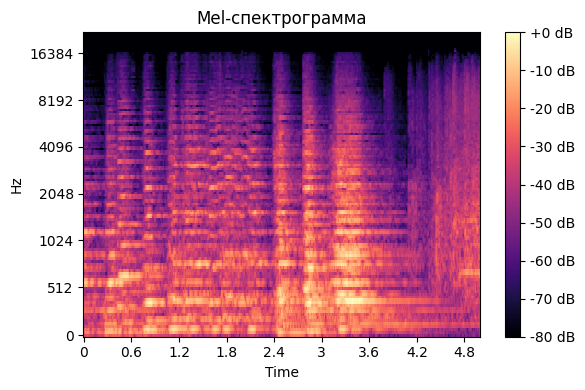

In [13]:
import requests

import librosa
import matplotlib.pyplot as plt
import numpy as np


audio_path = 'data/music/Hungarian_Dance_number_5.ogg'
signal, sample_rate = librosa.load(audio_path, sr=None, offset=35, duration=5)

n_fft = 2048
hop_length = int(n_fft / 4)
n_mels = 128

mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                                         n_fft=n_fft,
                                         hop_length=hop_length,
                                         n_mels=n_mels)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(6, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
            hop_length=hop_length,
            x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show()

In [14]:
# вычисление STFT (сглаживание по умолчанию)
stft = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length,
                   win_length=n_fft)

# спектрограмма энергий
power_spec = np.abs(stft)**2

# Mel-фильтры
mel_basis = librosa.filters.mel(sr=sample_rate, n_fft=n_fft, n_mels=n_mels)

# взвешивание энергетического спектра с помощью Mel-фильтров)
mel_spec = np.dot(mel_basis, power_spec)

# переход в децибелы
mel_spec_db_manual = librosa.power_to_db(mel_spec, ref=np.max)

# сравнение спектрограмм
if np.testing.assert_array_equal(mel_spec_db, mel_spec_db_manual):
    print("Успех! Спектрограммы совпали.")

Загрузите аудио файл с соло на трубе: с помощью librosa.

Постройте Mel-спектрограмму с произвольными параметрами и визуализируйте её.

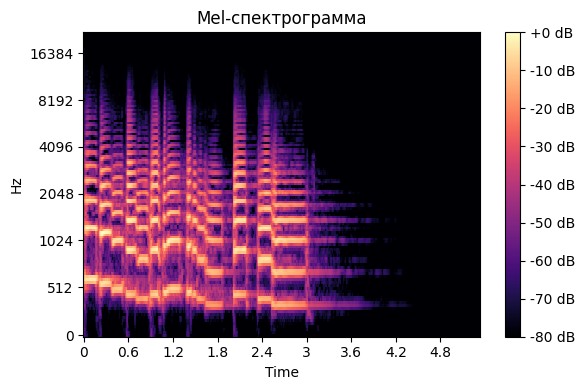

In [11]:
import requests

import librosa
import matplotlib.pyplot as plt
import numpy as np


url = "https://raw.githubusercontent.com/librosa/data/main/audio/sorohanro_-_solo-trumpet-06.hq.ogg"
response = requests.get(url, stream=True)

audio_path = 'data/music/solo_trumpet.ogg'
with open(audio_path, "wb") as f:
    f.write(response.content)

signal, sample_rate = librosa.load(audio_path, sr=None)

n_fft = 2048
hop_length = int(n_fft / 4)
n_mels = 128

mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                                         n_fft=n_fft,
                                         hop_length=hop_length,
                                         n_mels=n_mels)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)


plt.figure(figsize=(6, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
            hop_length=hop_length,
            x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show()

Посмотрим, как выглядят другие спектрограммы. STFT-спектр мы уже получали, когда поступательно вычисляли Mel-спектрограмму. Теперь давайте построим CQT-спектрограмму. Для этого используем метод librosa.cqt. Он так же принимает на вход несколько параметров: сам сигнал, sampling rate и шаг между окнами hop_length, а возвращает комплексное частотное представление сигнала, от которого мы будем брать модуль. Используем ранее загруженный аудио файл с игрой на трубе и визуализируем полученную спектрограмму.

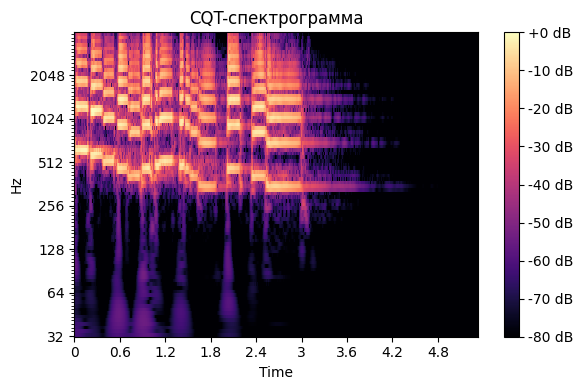

In [16]:
import librosa
import numpy as np
import matplotlib.pyplot as plt


audio_path = 'data/music/solo_trumpet.ogg'
signal, sample_rate = librosa.load(
    path=audio_path,
    sr=None)

# вычисление cqt-спектрограммы
hop_length = 64
cqt_spec = librosa.cqt(y=signal, sr=sample_rate,
                    hop_length=hop_length)

# преобразование в децибелы
cqt_spec_db = librosa.amplitude_to_db(np.abs(cqt_spec), ref=np.max)

# визуализация
plt.figure(figsize=(6, 4))
librosa.display.specshow(cqt_spec_db, sr=sample_rate,
            hop_length=hop_length,
            x_axis='time', y_axis='cqt_hz')

plt.colorbar(format='%+2.0f dB')
plt.title('CQT-спектрограмма')
plt.tight_layout()
plt.show()